In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import anndata as ad
import scanpy as sc
import cupy as cp
from sklearn.neighbors import KNeighborsClassifier

import time
import rapids_singlecell as rsc

import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

rmm.reinitialize(
    managed_memory=True, 
    pool_allocator=True,  
    devices=0  
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [2]:
sc.settings.set_figure_params(
    dpi=80,
    facecolor='white',
    frameon=False,
    fontsize=14,
    dpi_save=200,
    figsize=(6,6),
    format='png'
)

In [3]:
adata = sc.read_h5ad('../files/raw-all-tissdiss.h5ad')

In [4]:
adata = adata[adata.X.sum(axis=1) > 0]

mt_mask   = adata.var_names.str.startswith('MT-')
ribo_mask = adata.var_names.str.startswith(('RPS', 'RPL'))
ig_mask   = adata.var_names.str.startswith(('IGK', 'IGL', 'IGH'))

adata = adata[:, ~(mt_mask | ribo_mask | ig_mask)]
adata

View of AnnData object with n_obs × n_vars = 556792 × 18569
    obs: 'source_file', 'TIS_ID', 'project', 'original_barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'file_path', 'TIS_ID_base', 'in_cohort_metadata', 'flag', 'subject_id', 'cohort_label', 'tissue_type', 'sample_site', 'disease_state', 'age_at_collection', 'sex', 'race_ethnicity', 'treatment', 'pct_tumor', 'collection_year', 'biopsy_or_resection', 'old_labels'

### Rapids Workflow

In [5]:
adata = adata.copy()

In [6]:
rsc.get.anndata_to_GPU(adata)

In [7]:
rsc.pp.normalize_total(adata)
rsc.pp.log1p(adata)

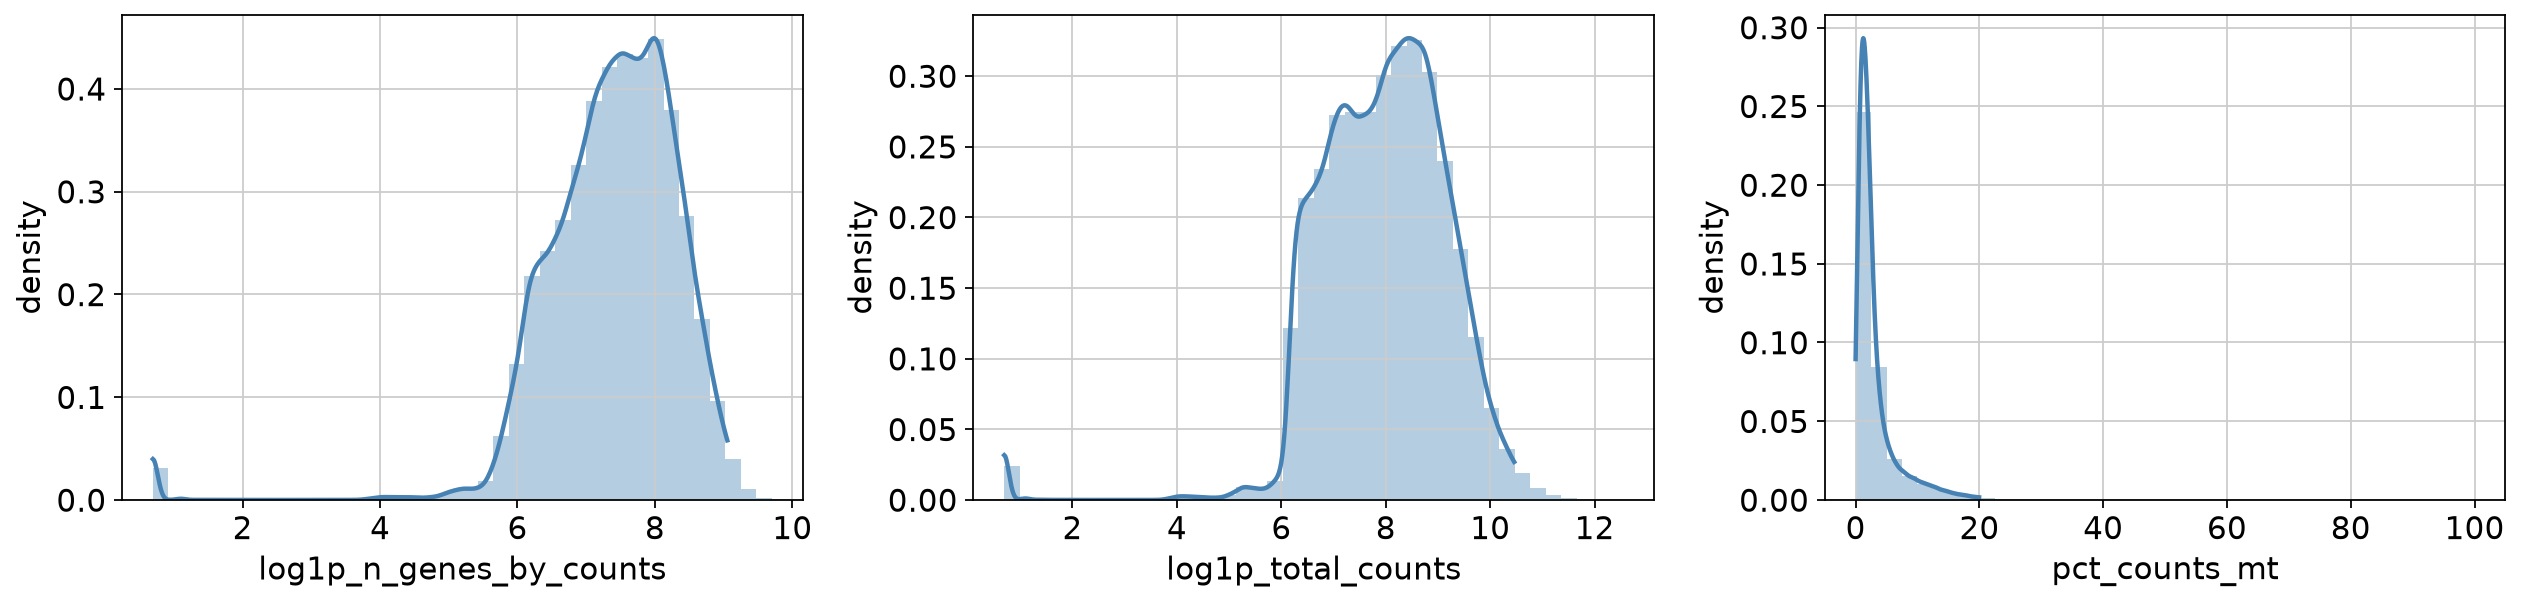

In [8]:
metrics = ['log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_mt']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, metrics):
  vals = adata.obs[col].values
  ax.hist(vals, bins=40, density=True, alpha=0.4, color='steelblue')
  xgrid = np.linspace(vals.min(), np.percentile(vals, 99), 500)
  ax.plot(xgrid, gaussian_kde(vals)(xgrid), color='steelblue', lw=2)
  ax.set_xlabel(col)
  ax.set_ylabel('density')

fig.tight_layout()

In [9]:
adata = adata[
      (adata.obs['log1p_n_genes_by_counts'] > 5) &
      (adata.obs['log1p_n_genes_by_counts'] < 9.8) &
      (adata.obs['log1p_total_counts'] > 5.5) &
      (adata.obs['log1p_total_counts'] < 11) &
      (adata.obs['pct_counts_mt'] < 6)
  ]

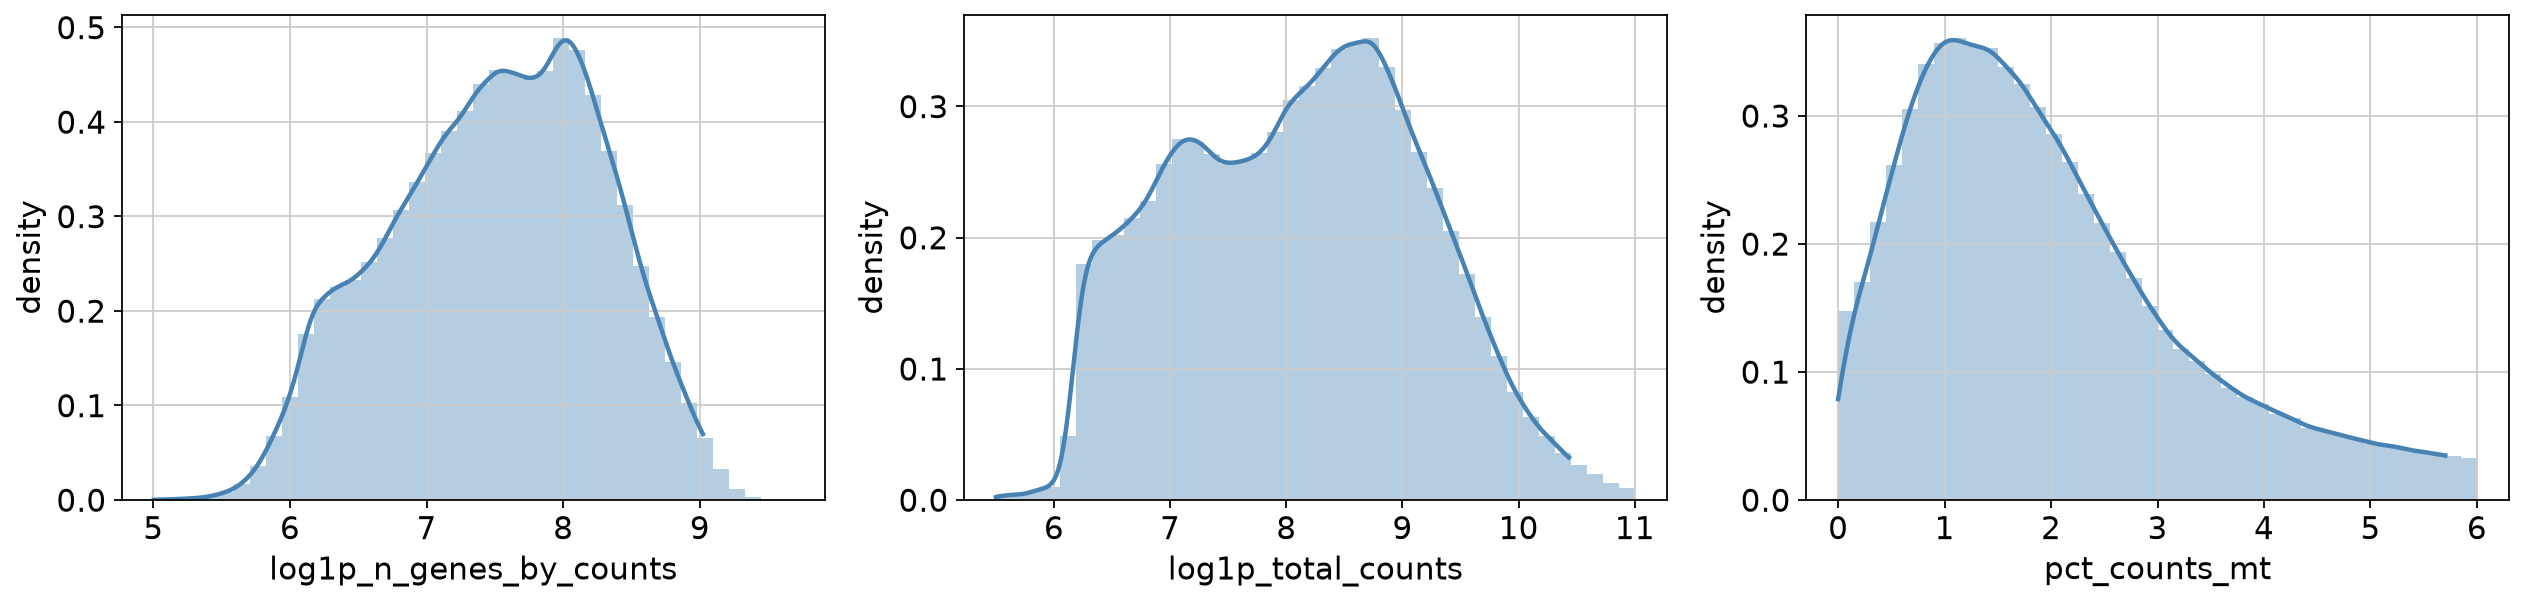

In [10]:
metrics = ['log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_mt']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, metrics):
  vals = adata.obs[col].values
  ax.hist(vals, bins=40, density=True, alpha=0.4, color='steelblue')
  xgrid = np.linspace(vals.min(), np.percentile(vals, 99), 500)
  ax.plot(xgrid, gaussian_kde(vals)(xgrid), color='steelblue', lw=2)
  ax.set_xlabel(col)
  ax.set_ylabel('density')

fig.tight_layout()

In [11]:
rsc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.25)
rsc.pp.scale(adata, max_value=10, zero_center=False)
rsc.tl.pca(adata, svd_solver='arpack')
adata.obsm['X_pca_temp'] = adata.obsm['X_pca']

In [12]:
rmm.reinitialize(managed_memory=False, pool_allocator=True, devices=0)
cp.cuda.set_allocator(rmm_cupy_allocator)
rsc.pp.harmony_integrate(adata, key=["source_file", "TIS_ID"], flavor="harmony1")

In [13]:
rsc.pp.neighbors(adata, n_neighbors=15, n_pcs=40, use_rep="X_pca_harmony", key_added="harmony")
rsc.tl.umap(adata, neighbors_key="harmony", key_added="X_umap_harmony", min_dist=0.001, spread=5)
rsc.tl.tsne(adata, n_pcs=40, early_exaggeration=12, learning_rate=200, use_rep="X_pca_harmony")
rsc.tl.leiden(adata, resolution=1.5, neighbors_key="harmony", key_added="leiden_harmony")

[2026-08-06 21:15:55.449] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


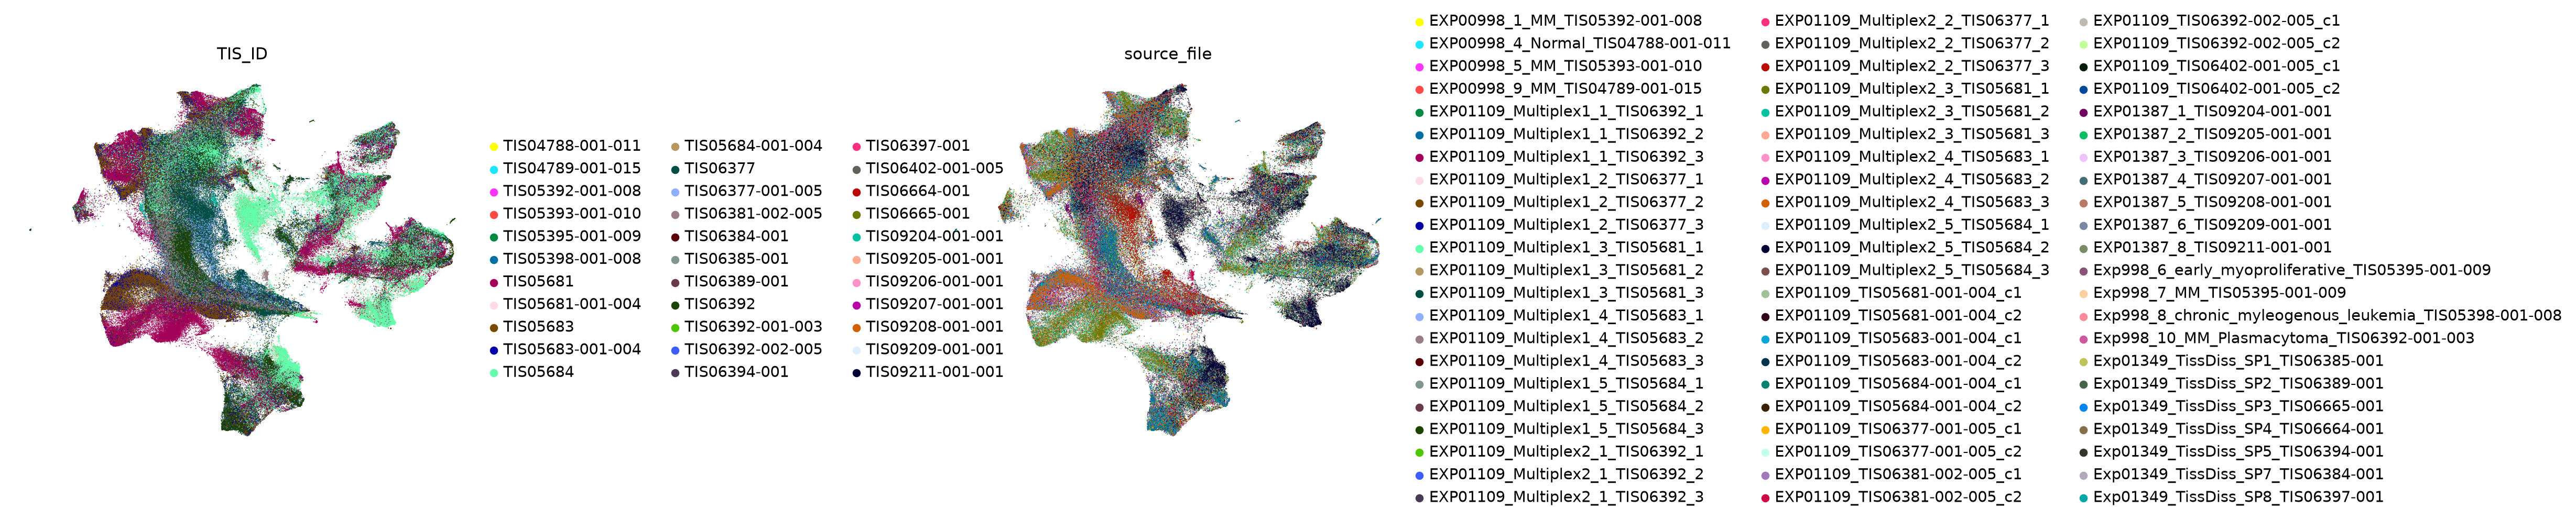

In [22]:
sc.pl.embedding(adata, basis="X_umap_harmony", color=["TIS_ID", "source_file"], wspace = 0.8, size=2)

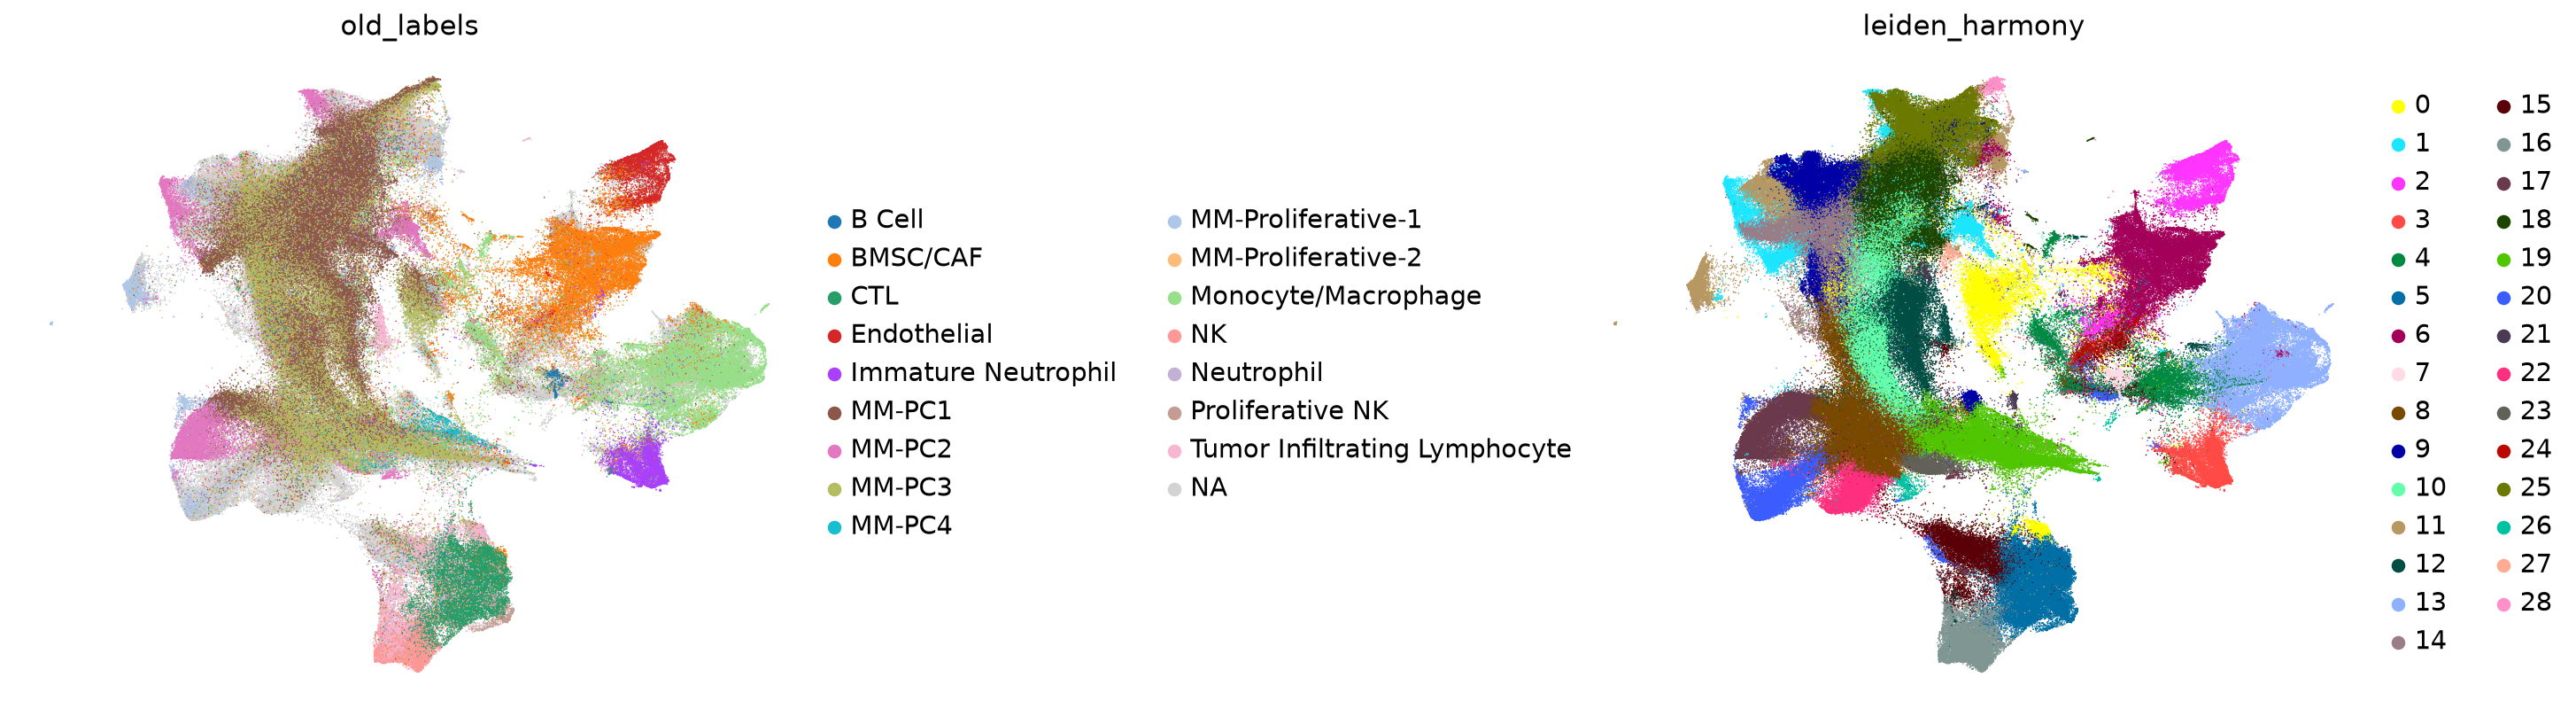

In [21]:
sc.pl.embedding(adata, basis="X_umap_harmony", color=["old_labels", "leiden_harmony"], wspace = 0.8, size=2)

In [16]:
# KNN label transfer for unmatched (new) cells in shared Harmony PCA space
n_nbh = 100

adata.obs['knn_labels'] = adata.obs['old_labels']
X = adata.obsm['X_umap_harmony']
labels = adata.obs['knn_labels'].copy()
known  = labels.notna()
unknown = labels.isna()

knn = KNeighborsClassifier(n_neighbors=n_nbh, weights='distance', n_jobs=-1)
knn.fit(X[known], labels[known])

adata.obs.loc[unknown, 'knn_labels'] = knn.predict(X[unknown])

proba = knn.predict_proba(X[unknown])
adata.obs['knn_confidence'] = np.nan
adata.obs.loc[unknown, 'knn_confidence'] = proba.max(axis=1)

print("KNN predictions:")
print(adata.obs.loc[unknown, 'knn_labels'].value_counts())
print(adata.obs.loc[unknown, 'knn_confidence'].describe())

KNN predictions:
knn_labels
MM-PC3                           72158
MM-PC1                           27057
MM-Proliferative-1               16631
BMSC/CAF                         13478
Monocyte/Macrophage              12433
MM-PC2                            9115
CTL                               7367
Tumor Infiltrating Lymphocyte     3058
MM-Proliferative-2                2449
Endothelial                       2266
MM-PC4                            2260
Immature Neutrophil               1745
NK                                 858
B Cell                             678
Proliferative NK                   103
Neutrophil                           3
Name: count, dtype: int64
count    171659.000000
mean          0.581338
std           0.195877
min           0.126354
25%           0.426440
50%           0.568521
75%           0.726439
max           1.000000
Name: knn_confidence, dtype: float64


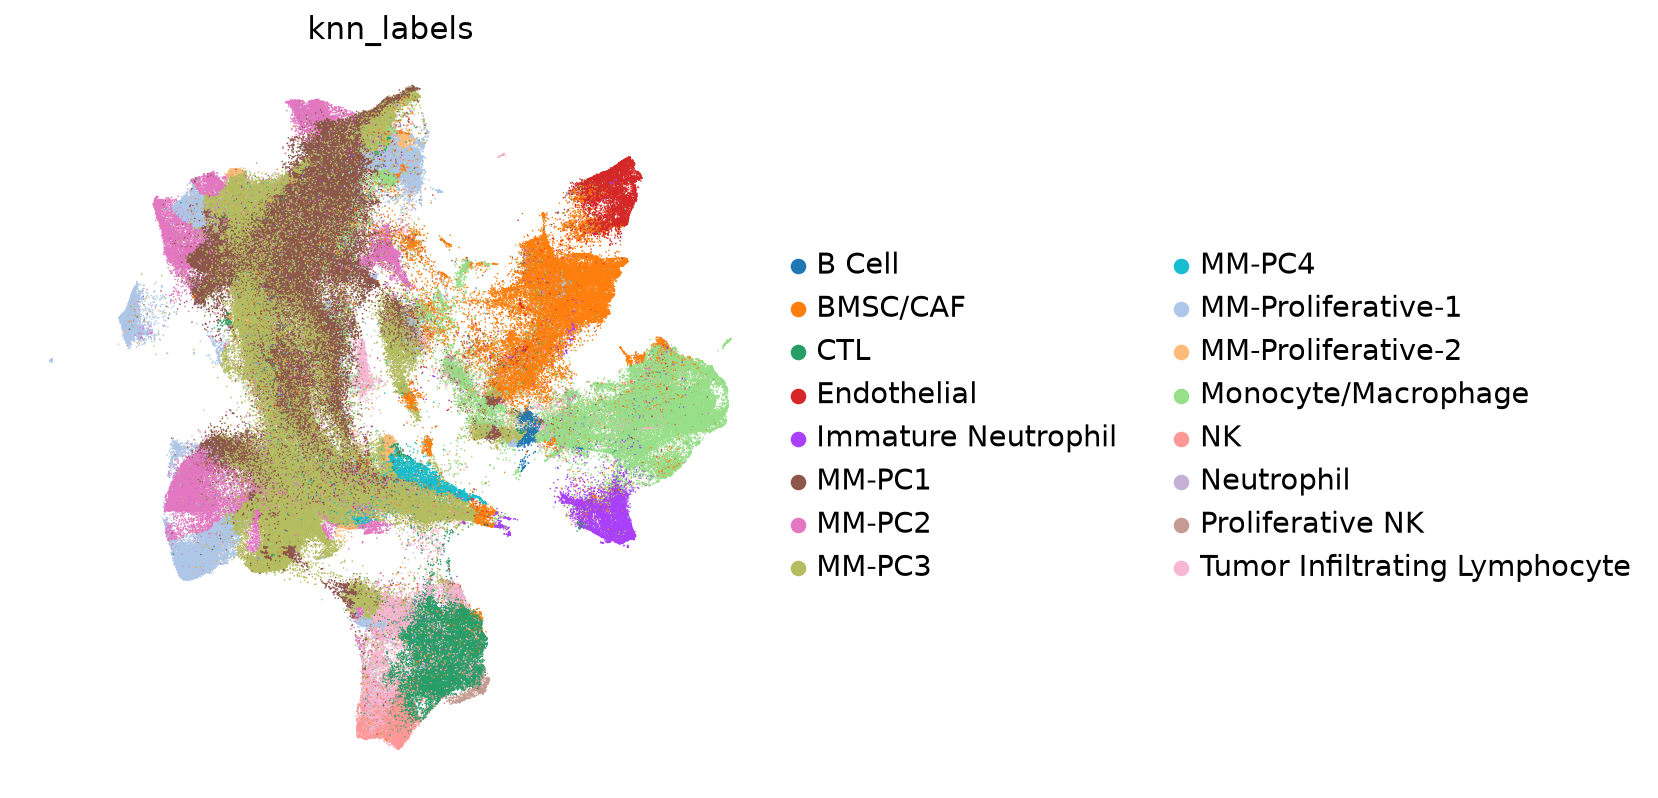

In [17]:
sc.pl.embedding(adata, basis="X_umap_harmony", color="knn_labels", size=2)

In [18]:
adata.write('../files/tissdiss_object.h5ad')

## Diffusion Maps

In [3]:
adata = sc.read_h5ad('../files/tissdiss_object.h5ad')

In [4]:
rsc.tl.diffmap(adata, neighbors_key="harmony")
# Due to an issue with plotting in Scanpy, we need to shift the first component of the diffusion map by removing the first column:
adata.obsm["X_diffmap"] = adata.obsm["X_diffmap"][:, 1:]

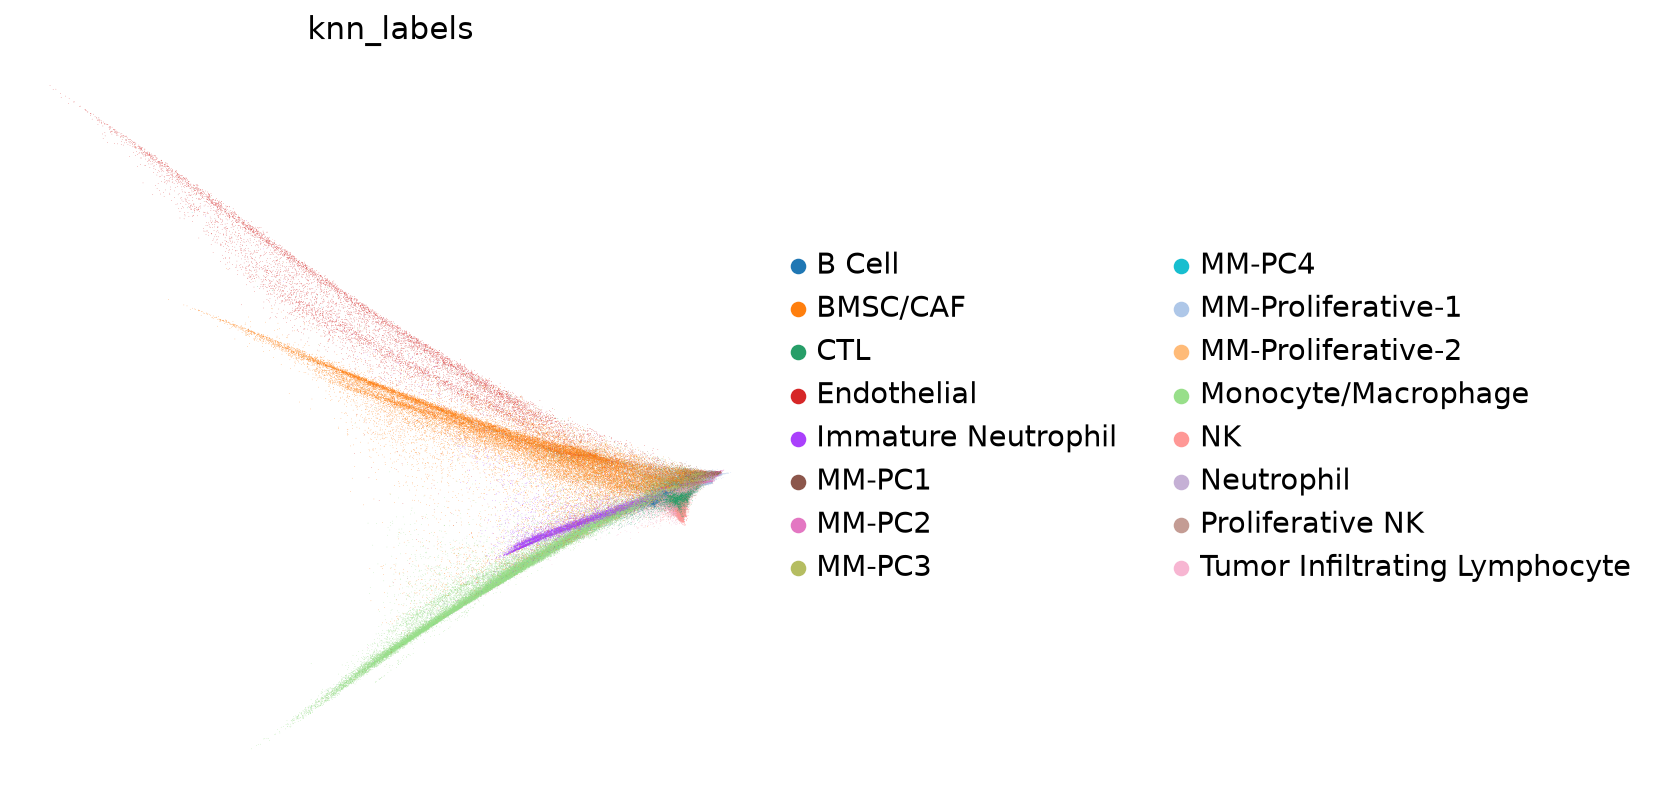

In [5]:
sc.pl.diffmap(adata, color="knn_labels")

## DEG Analysis

In [ ]:
sc.tl.rank_genes_groups(
    adata, groupby="knn_labels", method="logreg", key_added="logreg_knn_labels", use_raw=False
)

result = adata.uns['logreg_knn_labels']
groups = result['names'].dtype.names
df = pd.DataFrame(
    {group + '_' + key[:5]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj', 'scores']})

threshold = 0.05
significant_mask = pd.concat(
    [df[group + '_pvals'] < threshold for group in groups], axis=1).any(axis=1)
significant_df = df[significant_mask]
significant_df.head()
significant_df.to_csv('../files/rank_genes-logreg_knn_labels.csv')

In [ ]:
sc.tl.rank_genes_groups(
    adata, groupby="leiden_harmony", method="logreg", key_added="logreg_leiden_harmony", use_raw=False
)

result = adata.uns['logreg_leiden_harmony']
groups = result['names'].dtype.names
df = pd.DataFrame(
    {group + '_' + key[:5]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj', 'scores']})

threshold = 0.05
significant_mask = pd.concat(
    [df[group + '_pvals'] < threshold for group in groups], axis=1).any(axis=1)
significant_df = df[significant_mask]
significant_df.head()
significant_df.to_csv('../files/rank_genes-logreg_leiden_harmony.csv')

In [ ]:
adata.write('../files/tissdiss_object_with_ranks.h5ad')